# Network Traffic Classification — Visualization

This notebook is a visualization-friendly version of the uploaded preprocessing and model-training code.

**Workflow:** Load → Clean → Explore → Encode → Split → Scale → Train Random Forest → Evaluate → Visualize

The original preprocessing script strips column-name whitespace, replaces infinite values with NaN, drops missing rows, and identifies the target column as `Label` when available.

The original training script uses numeric features, `LabelEncoder`, an 80/20 stratified split, `StandardScaler`,`XGBoostClassifier` and a balanced `RandomForestClassifier`. 


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    confusion_matrix
)

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")


## 1. Load the dataset

In [2]:
DATA_PATH = "../data/dataset.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
display(df.head())


Dataset shape: (59706, 24)


,duration,total_fiat,total_biat,min_fiat,min_biat,max_fiat,max_biat,mean_fiat,mean_biat,flowPktsPerSecond,...,std_flowiat,min_active,mean_active,max_active,std_active,min_idle,mean_idle,max_idle,std_idle,traffic_type
0,119994459.0,119994459.0,119970125.0,0.0,0.0,1399330.0,1211310.0,2348.136257,513.267526,2373.792943,...,9107.759178,1753114.0,11300000.0,39438693.0,1.600000e+07,1014624.0,1139537.6,1208289.0,74997.385381,BROWSING
1,143704195.0,143704195.0,42106019.0,0.0,0.0,101572528.0,854818.0,6986.105737,636.898837,603.204381,...,345078.175888,143704195.0,144000000.0,143704195.0,0.000000e+00,101572528.0,102000000.0,101572528.0,0.000000,BROWSING
2,119994980.0,119994980.0,119966891.0,7.0,0.0,819852.0,819602.0,10201.919742,2341.411304,525.030297,...,17736.017265,-1.0,0.0,-1.0,0.000000e+00,-1.0,0.0,-1.0,0.000000,BROWSING
3,119292282.0,119292282.0,119260024.0,3.0,0.0,912990.0,866900.0,11947.148923,3354.712349,381.726288,...,24218.472201,-1.0,0.0,-1.0,0.000000e+00,-1.0,0.0,-1.0,0.000000,BROWSING
4,119772966.0,119772917.0,119772939.0,4.0,0.0,2894671.0,2923147.0,18210.873803,3644.280989,329.331412,...,31326.437353,2210292.0,8688035.0,15165778.0,9.160912e+06,1799762.0,2347216.5,2894671.0,774217.578682,BROWSING


## 2. Clean the data

In [3]:
# Strip spaces from column names
df.columns = df.columns.str.strip()

# Replace infinite values and remove missing rows
df.replace([np.inf, -np.inf], np.nan, inplace=True)

before = len(df)
df.dropna(inplace=True)
after = len(df)

print(f"Rows before cleaning: {before:,}")
print(f"Rows after cleaning:  {after:,}")
print(f"Rows removed:         {before-after:,}")

display(df.head())


Rows before cleaning: 59,706
Rows after cleaning:  59,706
Rows removed:         0


,duration,total_fiat,total_biat,min_fiat,min_biat,max_fiat,max_biat,mean_fiat,mean_biat,flowPktsPerSecond,...,std_flowiat,min_active,mean_active,max_active,std_active,min_idle,mean_idle,max_idle,std_idle,traffic_type
0,119994459.0,119994459.0,119970125.0,0.0,0.0,1399330.0,1211310.0,2348.136257,513.267526,2373.792943,...,9107.759178,1753114.0,11300000.0,39438693.0,1.600000e+07,1014624.0,1139537.6,1208289.0,74997.385381,BROWSING
1,143704195.0,143704195.0,42106019.0,0.0,0.0,101572528.0,854818.0,6986.105737,636.898837,603.204381,...,345078.175888,143704195.0,144000000.0,143704195.0,0.000000e+00,101572528.0,102000000.0,101572528.0,0.000000,BROWSING
2,119994980.0,119994980.0,119966891.0,7.0,0.0,819852.0,819602.0,10201.919742,2341.411304,525.030297,...,17736.017265,-1.0,0.0,-1.0,0.000000e+00,-1.0,0.0,-1.0,0.000000,BROWSING
3,119292282.0,119292282.0,119260024.0,3.0,0.0,912990.0,866900.0,11947.148923,3354.712349,381.726288,...,24218.472201,-1.0,0.0,-1.0,0.000000e+00,-1.0,0.0,-1.0,0.000000,BROWSING
4,119772966.0,119772917.0,119772939.0,4.0,0.0,2894671.0,2923147.0,18210.873803,3644.280989,329.331412,...,31326.437353,2210292.0,8688035.0,15165778.0,9.160912e+06,1799762.0,2347216.5,2894671.0,774217.578682,BROWSING


## 3. Dataset overview

In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

display(df.dtypes.to_frame("Data Type"))


Rows: 59706
Columns: 24


,Data Type
duration,float64
total_fiat,float64
total_biat,float64
min_fiat,float64
min_biat,float64
max_fiat,float64
max_biat,float64
mean_fiat,float64
mean_biat,float64
flowPktsPerSecond,float64


## 4. Target variable distribution

Target column: traffic_type


,Count
traffic_type,
BROWSING,10000
VPN-BROWSING,10000
VOIP,6485
VPN-VOIP,5576
VPN-FT,4704
P2P,4000
FT,3975
VPN-P2P,3415
VPN-CHAT,2839


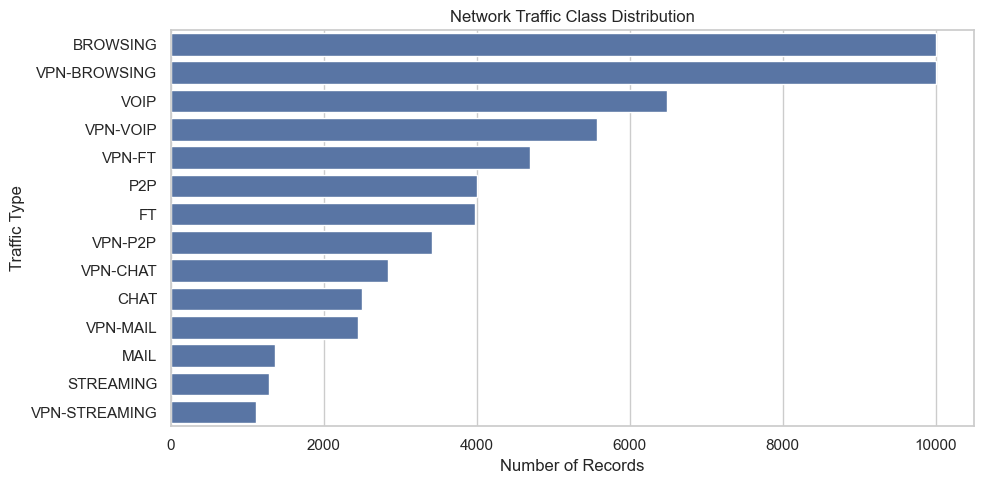

In [5]:
target_col = "Label" if "Label" in df.columns else df.columns[-1]

print("Target column:", target_col)
display(df[target_col].value_counts().to_frame("Count"))

plt.figure(figsize=(10, 5))
sns.countplot(data=df, y=target_col, order=df[target_col].value_counts().index)
plt.title("Network Traffic Class Distribution")
plt.xlabel("Number of Records")
plt.ylabel("Traffic Type")
plt.tight_layout()
plt.show()


## 5. Numeric feature exploration

In [6]:
numeric_df = df.select_dtypes(include=[np.number])

print("Number of numeric features:", numeric_df.shape[1])
display(numeric_df.describe().T.head(20))


Number of numeric features: 23


,count,mean,std,min,25%,50%,75%,max
duration,59706.0,2.354579e+07,3.610462e+07,0.0,256160.000000,1.306654e+07,2.998854e+07,646565983.0
total_fiat,59706.0,2.215066e+07,3.465348e+07,0.0,111687.500000,1.168921e+07,2.993403e+07,646565983.0
total_biat,59706.0,2.049105e+07,2.968948e+07,0.0,2625.000000,1.028447e+07,2.968528e+07,601185122.0
min_fiat,59706.0,2.044648e+06,7.919716e+06,-1.0,7.000000,6.400000e+01,3.090250e+03,119999708.0
min_biat,59706.0,1.779203e+06,7.455655e+06,-1.0,0.000000,2.000000e+01,5.037500e+02,119999620.0
max_fiat,59706.0,9.063199e+06,2.522047e+07,-1.0,25972.000000,5.371380e+05,9.829409e+06,646287731.0
max_biat,59706.0,7.591169e+06,1.704812e+07,-1.0,1738.000000,3.828470e+05,9.521396e+06,600109667.0
mean_fiat,59706.0,3.190482e+06,9.150407e+06,0.0,7927.111931,1.016749e+05,1.071742e+06,152000000.0
mean_biat,59706.0,2.776105e+06,8.073066e+06,0.0,336.445092,5.391917e+04,9.615569e+05,120000000.0
flowPktsPerSecond,59706.0,4.035707e+03,2.858908e+04,0.0,0.959502,8.545710e+00,1.001268e+02,2000000.0


## 6. Correlation heatmap

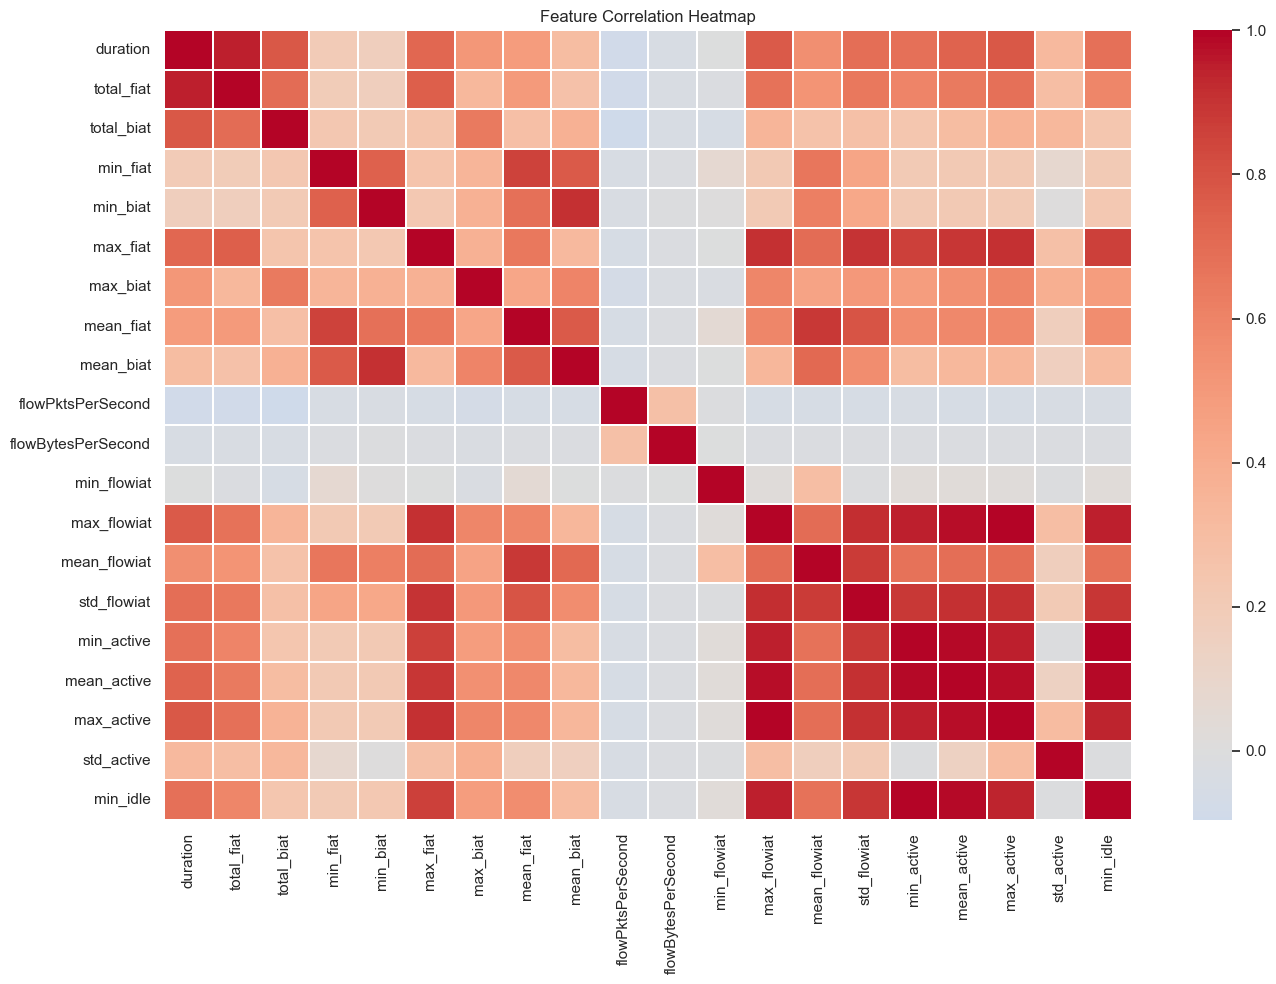

In [7]:
corr_features = numeric_df.columns[:20]

plt.figure(figsize=(14, 10))
sns.heatmap(
    numeric_df[corr_features].corr(),
    cmap="coolwarm",
    center=0,
    linewidths=0.3
)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()


## 7. Prepare features and target

In [8]:
X = df.drop(columns=[target_col])
X = X.select_dtypes(include=[np.number])

y = df[target_col]

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Feature matrix:", X.shape)
print("Classes:")
for i, name in enumerate(le.classes_):
    print(i, "→", name)


Feature matrix: (59706, 23)
Classes:
0 → BROWSING
1 → CHAT
2 → FT
3 → MAIL
4 → P2P
5 → STREAMING
6 → VOIP
7 → VPN-BROWSING
8 → VPN-CHAT
9 → VPN-FT
10 → VPN-MAIL
11 → VPN-P2P
12 → VPN-STREAMING
13 → VPN-VOIP


## 8. Train/test split and scaling

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 47764
Testing samples: 11942


## 9. Train XGBoost

In [10]:
# Train XGBoost
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    eval_metric="mlogloss"
)

xgb_model.fit(X_train_scaled, y_train)

# Predictions
xgb_predictions = xgb_model.predict(X_test_scaled)

# Calculate accuracy
xgb_accuracy = accuracy_score(y_test, xgb_predictions)

print(f"XGBoost Accuracy: {xgb_accuracy * 100:.2f}%")

XGBoost Accuracy: 85.94%


## 10. Train Random Forest

In [11]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_model.fit(X_train_scaled, y_train)

predictions = rf_model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, predictions)


print("Random Forest training complete.")


Random Forest training complete.


## 11. Random Forest vs XGBoost Accuracy

,Model,Accuracy
0,Random Forest,90.805560
1,XGBoost,85.940378


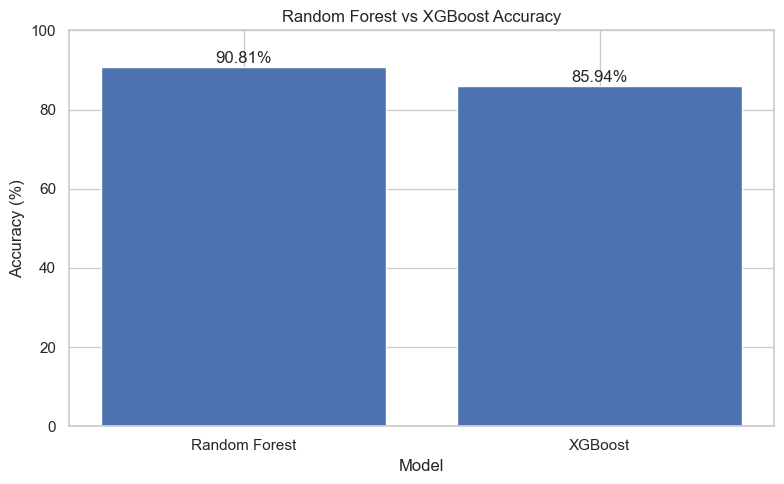

In [12]:
# Store both accuracies
model_names = ["Random Forest", "XGBoost"]
accuracies = [accuracy * 100, xgb_accuracy * 100]

# Create comparison DataFrame
comparison_df = pd.DataFrame({
    "Model": model_names,
    "Accuracy": accuracies
})

display(comparison_df)

# Plot comparison
plt.figure(figsize=(8, 5))

bars = plt.bar(model_names, accuracies)

plt.title("Random Forest vs XGBoost Accuracy")
plt.xlabel("Model")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)

# Display accuracy value above each bar
for bar, value in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f"{value:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

## 12. Model accuracy and classification report

In [13]:
predictions = rf_model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, predictions)

print(f"Overall Accuracy: {accuracy * 100:.2f}%")
print()
print(classification_report(
    y_test,
    predictions,
    target_names=le.classes_,
    zero_division=0
))


Overall Accuracy: 90.81%

               precision    recall  f1-score   support

     BROWSING       0.92      0.95      0.94      2000
         CHAT       0.86      0.83      0.85       501
           FT       0.94      0.73      0.82       795
         MAIL       0.91      0.79      0.84       273
          P2P       0.96      0.98      0.97       800
    STREAMING       0.92      0.84      0.88       257
         VOIP       0.99      0.97      0.98      1297
 VPN-BROWSING       0.92      0.91      0.91      2000
     VPN-CHAT       0.84      0.77      0.80       568
       VPN-FT       0.86      0.85      0.86       941
     VPN-MAIL       0.90      0.96      0.93       489
      VPN-P2P       0.71      0.97      0.82       683
VPN-STREAMING       0.99      0.98      0.98       223
     VPN-VOIP       0.97      0.95      0.96      1115

     accuracy                           0.91     11942
    macro avg       0.91      0.89      0.90     11942
 weighted avg       0.91      0.91   

## 13. Confusion matrix

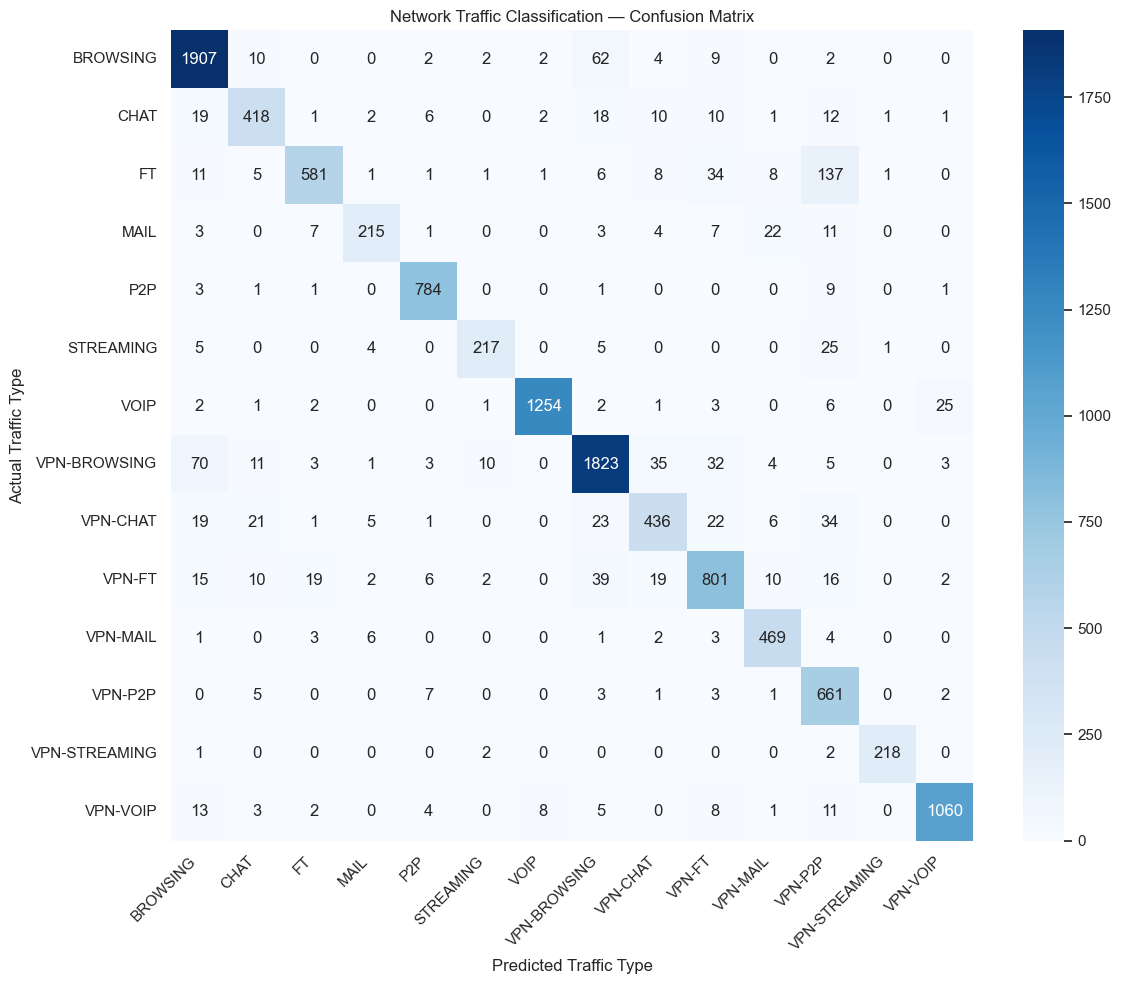

In [14]:
cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.title("Network Traffic Classification — Confusion Matrix")
plt.ylabel("Actual Traffic Type")
plt.xlabel("Predicted Traffic Type")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## 14. Top 10 feature importances

,Feature,Importance
0,flowBytesPerSecond,0.111496
1,min_flowiat,0.079634
2,max_flowiat,0.065550
3,min_fiat,0.065304
4,min_biat,0.064317
5,mean_flowiat,0.061867
6,flowPktsPerSecond,0.060132
7,mean_fiat,0.052966
8,mean_biat,0.052449
9,duration,0.051523


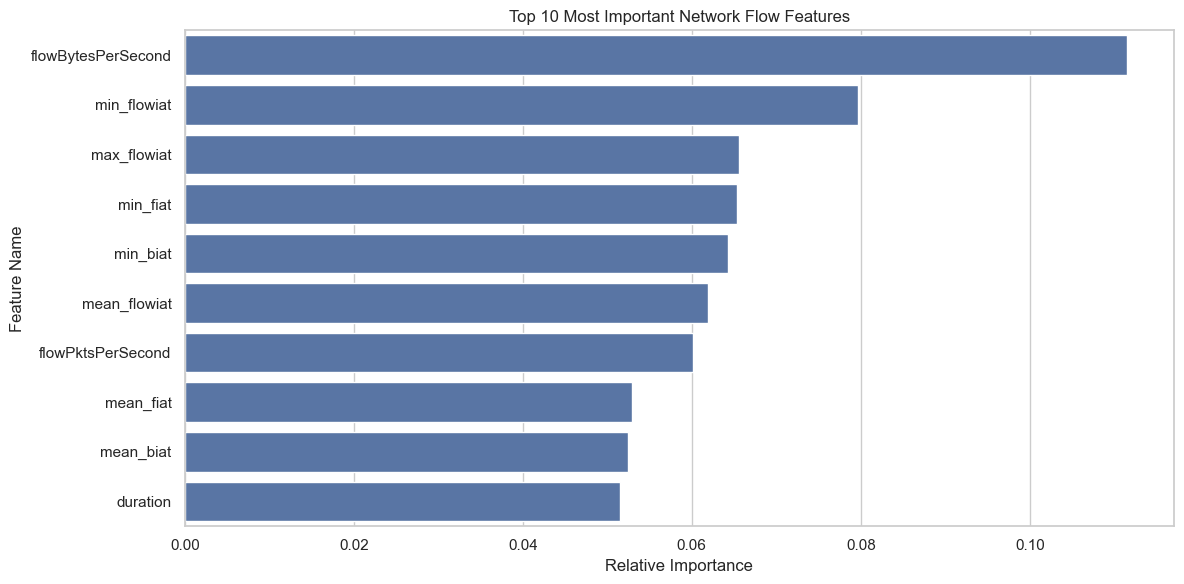

In [15]:
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1][:10]

top_features = X.columns[indices]
top_importances = importances[indices]

importance_df = pd.DataFrame({
    "Feature": top_features,
    "Importance": top_importances
})

display(importance_df)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Most Important Network Flow Features")
plt.xlabel("Relative Importance")
plt.ylabel("Feature Name")
plt.tight_layout()
plt.show()


In [16]:
import joblib
import os

# Create models directory if it doesn't exist
os.makedirs("models", exist_ok=True)

# Save Random Forest model
joblib.dump(rf_model, "models/random_forest_model.pkl")

# Save XGBoost model
joblib.dump(xgb_model, "models/xgboost_model.pkl")

print("✅ Both models saved successfully!")

✅ Both models saved successfully!
